# Dataset Modeling

In [2]:
import numpy as np
import os
import test_utils as utils
import cv2
import matplotlib.pyplot as plt

## Load the ACOD-12K Dataset of the Images and the Ground Trut segmentation masks

In [3]:
img_root_tr = "Datasets/ACOD-12K/Train/Imgs/"
gt_root_tr = "Datasets/ACOD-12K/Train/GT/"
img_root_te = "Datasets/ACOD-12K/Test/Imgs/"
gt_root_te = "Datasets/ACOD-12K/Test/GT/"

imgs = [img_root_tr + f for f in os.listdir(img_root_tr) if f.endswith('.png')]
imgs += [img_root_te + f for f in os.listdir(img_root_te) if f.endswith('.png')]
len(imgs)

6092

In [4]:
gts = [gt_root_tr + f for f in os.listdir(gt_root_tr) if f.endswith('.png')]
gts += [gt_root_te + f for f in os.listdir(gt_root_te) if f.endswith('.png')]
len(gts)

6092

In [5]:
imgs[0:5], gts[0:5]

(['Datasets/ACOD-12K/Train/Imgs/bean_left_00001.png',
  'Datasets/ACOD-12K/Train/Imgs/bean_left_00002.png',
  'Datasets/ACOD-12K/Train/Imgs/bean_left_00003.png',
  'Datasets/ACOD-12K/Train/Imgs/bean_left_00004.png',
  'Datasets/ACOD-12K/Train/Imgs/bean_left_00005.png'],
 ['Datasets/ACOD-12K/Train/GT/bean_left_00001.png',
  'Datasets/ACOD-12K/Train/GT/bean_left_00002.png',
  'Datasets/ACOD-12K/Train/GT/bean_left_00003.png',
  'Datasets/ACOD-12K/Train/GT/bean_left_00004.png',
  'Datasets/ACOD-12K/Train/GT/bean_left_00005.png'])

## Sample segmentation mask

(1080, 1920, 3)


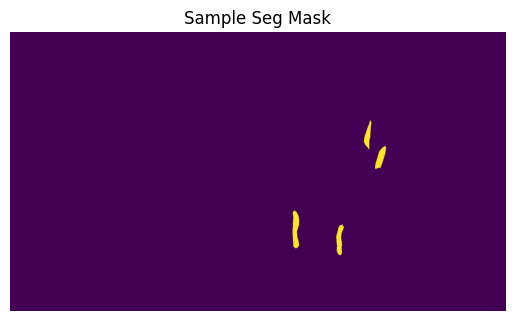

In [6]:
# Load image
image = cv2.imread(gts[1])

# Check if image loaded successfully
if image is None:
    print("Error loading image")
else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print(image.shape)
    plt.imshow(gray)
    plt.axis("off")  # Hide axes
    plt.title("Sample Seg Mask")
    plt.show()

3. Count each instance of a segment mask in an image and get count and area. (We are only counting the size of the masks because that is what affects the prediction.)
## Sample Segmentation Mask with bounding boxes 

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply the Component analysis function
#TotalLabels: NUMBER OF INSTANCES
#Values: Can be unpacked as x, y, w, h, area. Area has the total number of pixels
analysis = cv2.connectedComponentsWithStats(gray, 4, cv2.CV_32S)
(totalLabels, label_ids, values, centroid) = analysis

Label 1 has 1615 pixels!
Label 2 has 1959 pixels!
Label 3 has 2841 pixels!
Label 4 has 2132 pixels!


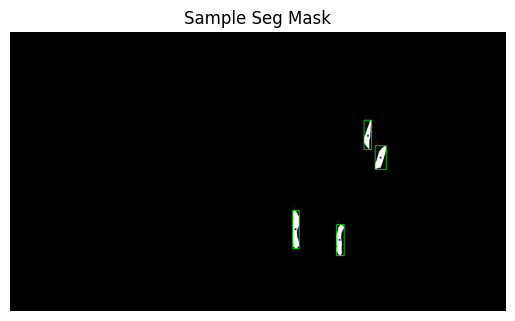

In [8]:
# Convert original image to color if it's grayscale (so we can draw colored boxes)
if len(image.shape) == 2:
    output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
else:
    output_image = image.copy()

# Draw bounding boxes and centroids
for label in range(1, totalLabels):
    x, y, w, h, area = values[label]
    cx, cy = centroid[label]

    print(f'Label {label} has {area} pixels!')
    
    # Draw rectangle
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Draw centroid
    cv2.circle(output_image, (int(cx), int(cy)), 4, (0, 0, 255), -1)

    # Put label number
    cv2.putText(output_image, f"{label}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
plt.imshow(output_image)
plt.axis("off")  # Hide axes
plt.title("Sample Seg Mask")
plt.show()

## Get the color space of the instances
The images are processed in batches where its instances are analyzed in a binary mask on a color image. It's mean, std, pixel count, and color differences to the surrounding background are computed. This serves as the feature-extraction step where its results are appended to the dataset to be used by the models.

In [12]:
def analyze_instances_with_mask(img_path, gt_path, buffer_size=2, vis=False, scale=2):
    import cv2
    import numpy as np

    filename = img_path.split("/")[4]
    crop = filename.split("_")[0]

    color_image = cv2.imread(img_path)
    binary_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    binary_mask = (binary_mask > 0).astype(np.uint8)

    mask = (binary_mask > 0).astype(np.uint8)

    num_labels, label_ids, stats, centroids = cv2.connectedComponentsWithStats(mask)

    output_image = color_image.copy()
    patch_size = 20

    instances = []

    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]
        cx, cy = centroids[label]

        instance_mask = (label_ids == label)

        instance_pixels = color_image[instance_mask]
        mean_color = np.mean(instance_pixels, axis=0).astype(np.uint8)
        std_color = np.std(instance_pixels, axis=0).astype(np.uint8)

        # ROI with padding
        x0 = max(x - buffer_size, 0)
        y0 = max(y - buffer_size, 0)
        x1 = min(x + w + buffer_size, color_image.shape[1])
        y1 = min(y + h + buffer_size, color_image.shape[0])

        roi = color_image[y0:y1, x0:x1]
        roi_label_ids = label_ids[y0:y1, x0:x1]

        # Buffer mask (background only)
        buffer_mask = (roi_label_ids == 0)

        surrounding_pixels = roi[buffer_mask]

        if len(surrounding_pixels) > 0:
            mean_surround_color = np.mean(surrounding_pixels, axis=0).astype(np.uint8)
        else:
            mean_surround_color = np.array([0, 0, 0], dtype=np.uint8)

        # CREATE FULL-SIZE BUFFER MASK (for drawing)
        buffer_mask_full = np.zeros_like(mask, dtype=np.uint8)
        buffer_mask_full[y0:y1, x0:x1] = buffer_mask.astype(np.uint8)

        # REMOVE FAR BACKGROUND (keep only near instance)
        kernel = np.ones((buffer_size*2+1, buffer_size*2+1), np.uint8)
        dilated_instance = cv2.dilate(instance_mask.astype(np.uint8), kernel)
        buffer_mask_full = buffer_mask_full & dilated_instance

        instance = {
            "crop": crop,
            "filename": filename,
            "instance": label,
            "area": area,
            "pixels": instance_pixels.tolist(),
            "buffer_pixels": surrounding_pixels.tolist()
        }

        if vis:
            color_diff = mean_color.astype(int) - mean_surround_color.astype(int)

            # INSTANCE CONTOUR (green)
            contours, _ = cv2.findContours(instance_mask.astype(np.uint8),
                                           cv2.RETR_EXTERNAL,
                                           cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(output_image, contours, -1, (0, 255, 0), 2)

            # BUFFER CONTOUR (yellow)
            buffer_contours, _ = cv2.findContours(buffer_mask_full.astype(np.uint8),
                                                  cv2.RETR_EXTERNAL,
                                                  cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(output_image, buffer_contours, -1, (0, 255, 255), 2)

            # Centroid
            cv2.circle(output_image, (int(cx), int(cy)), 4, (0, 0, 255), -1)

            # Label
            cv2.putText(output_image, f"{label}", (x, y - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

            # Area
            cv2.putText(output_image, f"{area}px", (x, y + h + 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)

            # Mean color patch
            cv2.rectangle(output_image, (x + w + 5, y),
                          (x + w + 5 + patch_size, y + patch_size),
                          mean_color.tolist(), -1)

            # Text
            cv2.putText(output_image,
                        f"σ:{std_color[0]},{std_color[1]},{std_color[2]}",
                        (x + w + 5, y + patch_size + 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 255, 255), 1)

            cv2.putText(output_image,
                        f"Δ:{color_diff[0]},{color_diff[1]},{color_diff[2]}",
                        (x + w + 5, y + patch_size + 25),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 255, 255), 1)

        instances.append(instance)

    #UPSCALE
    if scale != 1:
        output_image = cv2.resize(
            output_image,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_CUBIC
        )

    return output_image, instances

| AREA: 3439 |
| AREA: 17773 |
| AREA: 1076 |
| AREA: 2031 |
| AREA: 2083 |
| AREA: 1214 |
| AREA: 1859 |
| AREA: 534 |
| AREA: 7647 |
| AREA: 1870 |
| AREA: 13277 |
| AREA: 15626 |
| AREA: 5191 |
| AREA: 2753 |
| AREA: 1267 |
| AREA: 1025 |
| AREA: 6253 |


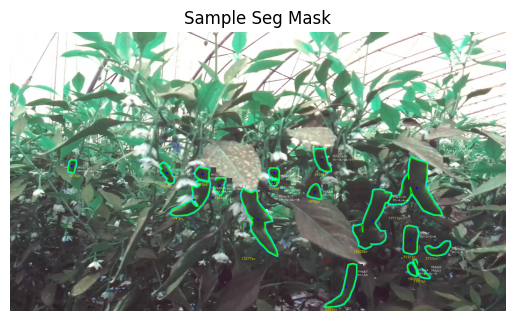

In [18]:
# Analyze instances
output_image, instances = analyze_instances_with_mask(imgs[5200], gts[5200], buffer_size=3, vis=True)

for instance in instances:
    print("==============")
    print("| AREA:", instance["area"], "|")
print("==============")

# Show result
plt.imshow(output_image)
plt.axis("off")  # Hide axes
plt.title("Sample Seg Mask")
plt.show()

In [ ]:
import pandas as pd
def process_images_to_csv(img_paths, mask_paths, csv_path, buffer_size=2, vis=False):
    all_instances = []

    i=0
    for img_path, mask_path in zip(img_paths, mask_paths):
        print("I:", i)
        _, instances = analyze_instances_with_mask(img_path, mask_path, buffer_size=buffer_size, vis=vis)
        all_instances.extend(instances)

        i+=1

    df = pd.DataFrame(all_instances)
    df.to_csv(csv_path, index=False)
    print(f"CSV saved successfully at {csv_path}!")

In [ ]:
process_images_to_csv(imgs[0:2000], gts[0:2000], "./Results/ClassCharacteristics1_B3.csv", buffer_size=3, vis=False)

I: 0
I: 1
I: 2
I: 3
I: 4
I: 5
I: 6
I: 7
I: 8
I: 9
I: 10
I: 11
I: 12
I: 13
I: 14
I: 15
I: 16
I: 17
I: 18
I: 19
I: 20
I: 21
I: 22
I: 23
I: 24
I: 25
I: 26
I: 27
I: 28
I: 29
I: 30
I: 31
I: 32
I: 33
I: 34
I: 35
I: 36
I: 37
I: 38
I: 39
I: 40
I: 41
I: 42
I: 43
I: 44
I: 45
I: 46
I: 47
I: 48
I: 49
I: 50
I: 51
I: 52
I: 53
I: 54
I: 55
I: 56
I: 57
I: 58
I: 59
I: 60
I: 61
I: 62
I: 63
I: 64
I: 65
I: 66
I: 67
I: 68
I: 69
I: 70
I: 71
I: 72
I: 73
I: 74
I: 75
I: 76
I: 77
I: 78
I: 79
I: 80
I: 81
I: 82
I: 83
I: 84
I: 85
I: 86
I: 87
I: 88
I: 89
I: 90
I: 91
I: 92
I: 93
I: 94
I: 95
I: 96
I: 97
I: 98
I: 99
I: 100
I: 101
I: 102
I: 103
I: 104
I: 105
I: 106
I: 107
I: 108
I: 109
I: 110
I: 111
I: 112
I: 113
I: 114
I: 115
I: 116
I: 117
I: 118
I: 119
I: 120
I: 121
I: 122
I: 123
I: 124
I: 125
I: 126
I: 127
I: 128
I: 129
I: 130
I: 131
I: 132
I: 133
I: 134
I: 135
I: 136
I: 137
I: 138
I: 139
I: 140
I: 141
I: 142
I: 143
I: 144
I: 145
I: 146
I: 147
I: 148
I: 149
I: 150
I: 151
I: 152
I: 153
I: 154
I: 155
I: 156
I: 157
I: 1

In [ ]:
process_images_to_csv(imgs[2000:4000], gts[2000:4000], "./Results/ClassCharacteristics2_B3.csv", buffer_size=3, vis=False)

I: 0
I: 1
I: 2
I: 3
I: 4
I: 5
I: 6
I: 7
I: 8
I: 9
I: 10
I: 11
I: 12
I: 13
I: 14
I: 15
I: 16
I: 17
I: 18
I: 19
I: 20
I: 21
I: 22
I: 23
I: 24
I: 25
I: 26
I: 27
I: 28
I: 29
I: 30
I: 31
I: 32
I: 33
I: 34
I: 35
I: 36
I: 37
I: 38
I: 39
I: 40
I: 41
I: 42
I: 43
I: 44
I: 45
I: 46
I: 47
I: 48
I: 49
I: 50
I: 51
I: 52
I: 53
I: 54
I: 55
I: 56
I: 57
I: 58
I: 59
I: 60
I: 61
I: 62
I: 63
I: 64
I: 65
I: 66
I: 67
I: 68
I: 69
I: 70
I: 71
I: 72
I: 73
I: 74
I: 75
I: 76
I: 77
I: 78
I: 79
I: 80
I: 81
I: 82
I: 83
I: 84
I: 85
I: 86
I: 87
I: 88
I: 89
I: 90
I: 91
I: 92
I: 93
I: 94
I: 95
I: 96
I: 97
I: 98
I: 99
I: 100
I: 101
I: 102
I: 103
I: 104
I: 105
I: 106
I: 107
I: 108
I: 109
I: 110
I: 111
I: 112
I: 113
I: 114
I: 115
I: 116
I: 117
I: 118
I: 119
I: 120
I: 121
I: 122
I: 123
I: 124
I: 125
I: 126
I: 127
I: 128
I: 129
I: 130
I: 131
I: 132
I: 133
I: 134
I: 135
I: 136
I: 137
I: 138
I: 139
I: 140
I: 141
I: 142
I: 143
I: 144
I: 145
I: 146
I: 147
I: 148
I: 149
I: 150
I: 151
I: 152
I: 153
I: 154
I: 155
I: 156
I: 157
I: 1

In [ ]:
process_images_to_csv(imgs[4000:6092], gts[4000:6092], "./Results/ClassCharacteristics3_B3.csv", buffer_size=3, vis=False)

I: 0
I: 1
I: 2
I: 3
I: 4
I: 5
I: 6
I: 7
I: 8
I: 9
I: 10
I: 11
I: 12
I: 13
I: 14
I: 15
I: 16
I: 17
I: 18
I: 19
I: 20
I: 21
I: 22
I: 23
I: 24
I: 25
I: 26
I: 27
I: 28
I: 29
I: 30
I: 31
I: 32
I: 33
I: 34
I: 35
I: 36
I: 37
I: 38
I: 39
I: 40
I: 41
I: 42
I: 43
I: 44
I: 45
I: 46
I: 47
I: 48
I: 49
I: 50
I: 51
I: 52
I: 53
I: 54
I: 55
I: 56
I: 57
I: 58
I: 59
I: 60
I: 61
I: 62
I: 63
I: 64
I: 65
I: 66
I: 67
I: 68
I: 69
I: 70
I: 71
I: 72
I: 73
I: 74
I: 75
I: 76
I: 77
I: 78
I: 79
I: 80
I: 81
I: 82
I: 83
I: 84
I: 85
I: 86
I: 87
I: 88
I: 89
I: 90
I: 91
I: 92
I: 93
I: 94
I: 95
I: 96
I: 97
I: 98
I: 99
I: 100
I: 101
I: 102
I: 103
I: 104
I: 105
I: 106
I: 107
I: 108
I: 109
I: 110
I: 111
I: 112
I: 113
I: 114
I: 115
I: 116
I: 117
I: 118
I: 119
I: 120
I: 121
I: 122
I: 123
I: 124
I: 125
I: 126
I: 127
I: 128
I: 129
I: 130
I: 131
I: 132
I: 133
I: 134
I: 135
I: 136
I: 137
I: 138
I: 139
I: 140
I: 141
I: 142
I: 143
I: 144
I: 145
I: 146
I: 147
I: 148
I: 149
I: 150
I: 151
I: 152
I: 153
I: 154
I: 155
I: 156
I: 157
I: 1